## Plot viz


In [79]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
from R_utilities import mappatura_dataset,mappatura_modelli
# Definisci la cartella contenente i file CSV
import glob
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import pearsonr
import os


In [80]:
cartella_output = '../output_def/'  # Sostituisci con il percorso corretto

## R1: Ghost Annotators across model and datasets

1285 2094
21895 39461
19879 39461
189 627
304 627
132 4554
1247 2094
1717 2094
141 4554
171 627
31578 39461
76 4554
18895 39461
604 4554
1248 2094
119 627
     model_name dataset_name  percentuale
0  Llama-3.2-1B         cade    61.365807
1  Llama-3.2-1B       corpus    55.485163
2    Qwen2.5-7B       corpus    50.376321
3  Llama-3.1-8B    attitudes    30.143541
4    Qwen2.5-7B    attitudes    48.484848


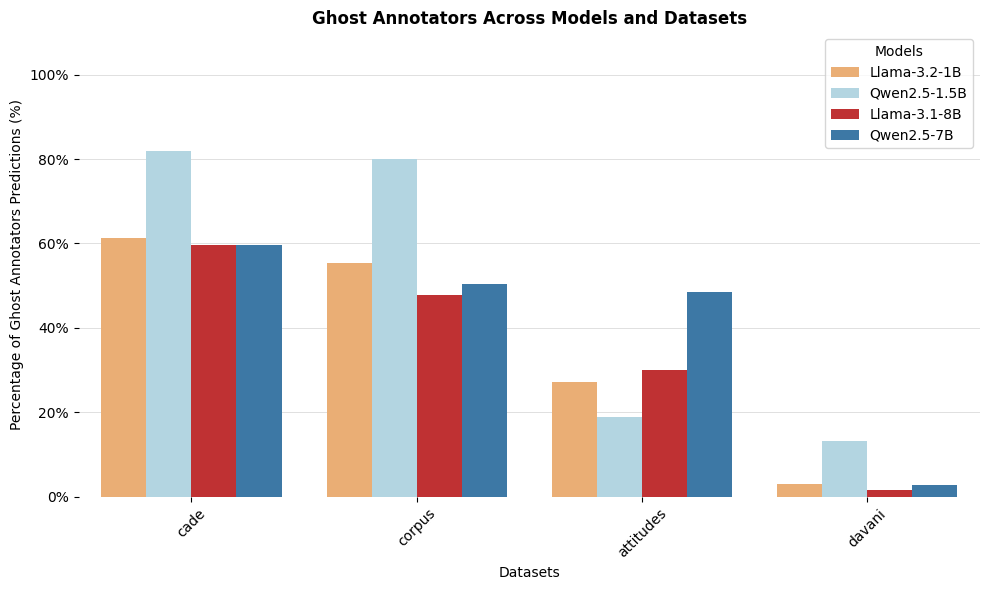

In [86]:
# Funzione per calcolare la percentuale di predizioni del modello mai selezionate dagli annotatori
def calcola_percentuale_predizioni(file_csv):
    # Leggi il file CSV
    df = pd.read_csv(file_csv)

    # Raggruppa i dati per comment_id e annotator_id
    annotazioni_umanes = df[['comment_id', 'label']].drop_duplicates()

    # Unisce con le predizioni del modello per calcolare la percentuale
    predizioni_modello = df[['comment_id', 'label_model']].drop_duplicates()

    # Raggruppiamo le etichette degli annotatori per ogni comment_id
    annotazioni_per_comment_id = annotazioni_umanes.groupby('comment_id')['label'].apply(set).reset_index()

    # Aggiungiamo le etichette degli annotatori al DataFrame delle predizioni
    df_completo = pd.merge(predizioni_modello, annotazioni_per_comment_id, on='comment_id', how='left')

    count=0
    for index, row in df_completo.iterrows():

        if row['label_model'] not in row['label']:
            #print(row)
            count+=1
    
    print(count,df['comment_id'].nunique())

    # Calcola la percentuale di predizioni "mai selezionate" rispetto al totale delle predizioni per ogni modello e dataset
    model_name, dataset_name = file_csv.split('_')[3].split('Instruct')[0][0:-1], file_csv.split('_')[-1].split(".")[0]
    
    if count==0:
        percentuale=0
    else:
        percentuale = count/df['comment_id'].nunique() * 100
    return model_name, dataset_name, percentuale

# Lista dei file CSV nella cartella di output
file_csvs = [f for f in os.listdir(cartella_output) if f.startswith('step_1_') and f.endswith('.csv')]

# Crea un DataFrame vuoto per contenere i risultati
dati_per_grafico = []

# Calcola la percentuale per ogni file CSV
for file_csv in file_csvs:
    model_name, dataset_name, percentuale = calcola_percentuale_predizioni(os.path.join(cartella_output, file_csv))
    dati_per_grafico.append([model_name, dataset_name, percentuale])

# Crea un DataFrame con i risultati
df_risultati = pd.DataFrame(dati_per_grafico, columns=['model_name', 'dataset_name', 'percentuale'])

print(df_risultati.head())


# Creazione del grafico
plt.figure(figsize=(10, 6))

# Grafico a barre raggruppate con seaborn
modelli_ordinati = ['Llama-3.2-1B',  'Qwen2.5-1.5B','Llama-3.1-8B','Qwen2.5-7B']  # Sostituisci con i tuoi nomi di modello


sns.barplot(x='dataset_name', y='percentuale', hue='model_name', data=df_risultati,  hue_order=modelli_ordinati, palette=['#fdae61','#abd9e9','#d7191c','#2c7bb6'], zorder=3)


plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y:.0f}%'))
plt.ylim(0, 110)
plt.legend(title="Models")
plt.grid(axis='y', color='lightgray', linestyle='-', linewidth=0.5, zorder=0)  # Griglia orizzontale, grigia chiara
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_visible(False)
plt.gca().spines['bottom'].set_visible(False)
# Aggiungi titoli e etichette
plt.title('Ghost Annotators Across Models and Datasets', fontweight='bold')
plt.xlabel('Datasets')
plt.ylabel('Percentage of Ghost Annotators Predictions (%)')
plt.xticks(rotation=45)
plt.tight_layout()

# Mostra il grafico

#Save in pdf
if not os.path.exists('figures'):
    os.makedirs('figures')
plt.savefig('figures/ghost_annotators_across_models_datasets.pdf', format='pdf', bbox_inches='tight')
plt.show()


## R2: Hallucinations actoss models and Datasets

attitudes ../data/measuring_hatespeech/attitudes - hate speech.csv 0.0 627 627
corpus ../data/measuring_hatespeech/corpus - violence.csv 0.0 39461 39461
cade ../data/measuring_hatespeech/cade - acceptability.csv 0.0 2094 2094
corpus ../data/measuring_hatespeech/corpus - violence.csv 0.0 39461 39461
cade ../data/measuring_hatespeech/cade - acceptability.csv 0.0 2094 2094
attitudes ../data/measuring_hatespeech/attitudes - hate speech.csv 0.0 627 627
davani ../data/measuring_hatespeech/davani - offensiveness.csv 0.0 4554 4554
cade ../data/measuring_hatespeech/cade - acceptability.csv 0.0 2094 2094
cade ../data/measuring_hatespeech/cade - acceptability.csv 0.0 2094 2094
davani ../data/measuring_hatespeech/davani - offensiveness.csv 0.0 4554 4554
davani ../data/measuring_hatespeech/davani - offensiveness.csv 0.0 4554 4554
corpus ../data/measuring_hatespeech/corpus - violence.csv 0.0 39461 39461
attitudes ../data/measuring_hatespeech/attitudes - hate speech.csv 0.0 627 627
davani ../data/mea

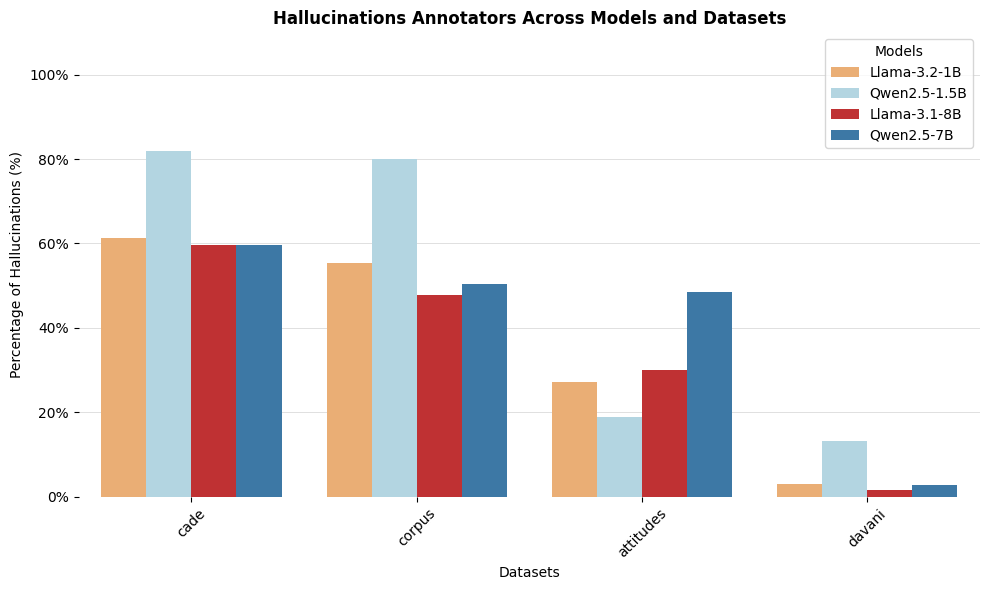

In [87]:
# Definisci la cartella contenente i file CSV
cartella_output = '../output_def'  # Sostituisci con il percorso corretto


# Funzione per calcolare la percentuale di predizioni del modello mai selezionate dagli annotatori
def calcola_percentuale_predizioni(file_csv):
    # Leggi il file CSV
    df = pd.read_csv(file_csv)

    # Raggruppa i dati per comment_id e annotator_id
    n_commenti_predetti = df['comment_id'].nunique()
    dataset = file_csv.split("_")[-1].split(".")[0]
    dataset_base_file=glob.glob(f"../data/measuring_hatespeech/{dataset} - *")[0]

    df = pd.read_csv(dataset_base_file)
    df = df.dropna(subset=['text', 'label', 'annotator_id', 'social_group'])
    df = df.dropna(subset=['comment_id', 'text', 'label', 'annotator_id', 'social_group'])

    df = df.dropna(subset=['label'])
    n_commenti = df['comment_id'].nunique()


    model_name, dataset_name = file_csv.split('_')[3].split('Instruct')[0][0:-1], file_csv.split('_')[-1].split(".")[0]
    #print(file_csv,model_name,dataset_name)

    if n_commenti_predetti==0:
        percentuale=0
    else:
        percentuale = (n_commenti-n_commenti_predetti)/n_commenti * 100
    print(dataset_name,dataset_base_file,percentuale,n_commenti,n_commenti_predetti)
    return model_name, dataset_name, percentuale

# Lista dei file CSV nella cartella di output
file_csvs = [f for f in os.listdir(cartella_output) if f.startswith('results_') and f.endswith('.csv')]

# Crea un DataFrame vuoto per contenere i risultati
dati_per_grafico = []

# Calcola la percentuale per ogni file CSV
for file_csv in file_csvs:
    if "Thinking" in file_csv:
        continue
    model_name, dataset_name, percentuale = calcola_percentuale_predizioni(os.path.join(cartella_output, file_csv))
    dati_per_grafico.append([model_name, dataset_name, percentuale])

print(dati_per_grafico)

# Creazione del grafico
plt.figure(figsize=(10, 6))

# Grafico a barre raggruppate con seaborn
modelli_ordinati = ['Llama-3.2-1B',  'Qwen2.5-1.5B','Llama-3.1-8B','Qwen2.5-7B']  # Sostituisci con i tuoi nomi di modello


print(df_risultati['model_name'].unique())
sns.barplot(x='dataset_name', y='percentuale', hue='model_name', data=df_risultati,  hue_order=modelli_ordinati, palette=['#fdae61','#abd9e9','#d7191c','#2c7bb6'], zorder=3)

plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y:.0f}%'))
plt.ylim(0, 110)
plt.legend(title="Models")
plt.grid(axis='y', color='lightgray', linestyle='-', linewidth=0.5, zorder=0)  # Griglia orizzontale, grigia chiara
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_visible(False)
plt.gca().spines['bottom'].set_visible(False)
# Aggiungi titoli e etichette
plt.title('Hallucinations Annotators Across Models and Datasets', fontweight='bold')
plt.xlabel('Datasets')
plt.ylabel('Percentage of Hallucinations (%)')
plt.xticks(rotation=45)
plt.tight_layout()

# Mostra il grafico
plt.show()

## R3: Cumulative Distibution of the number of annotators

attitudes 3 6
cade 3 7
corpus 1 804
davani 9 196


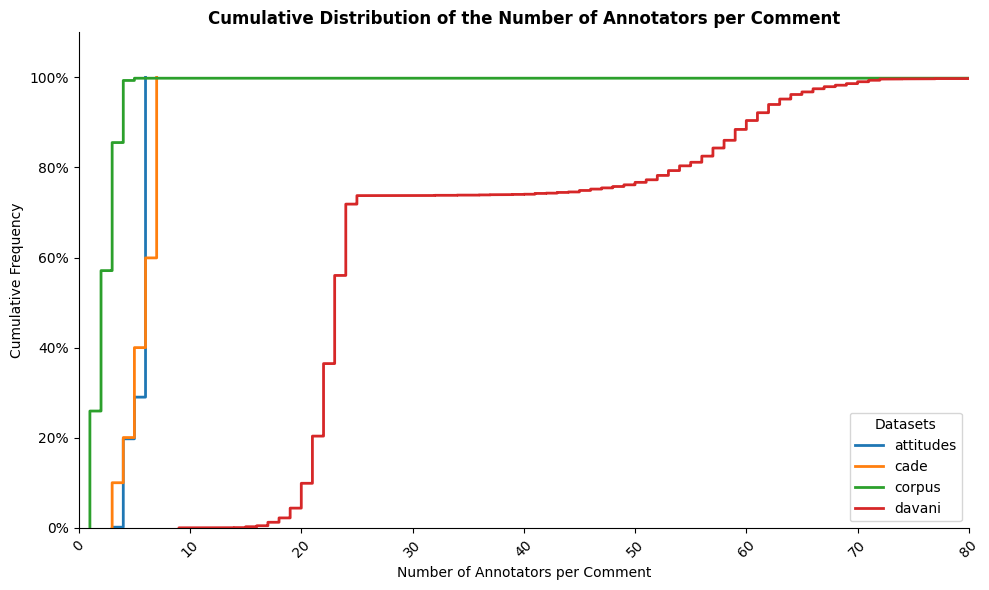

In [59]:
# Lista dei file CSV da caricare
files = ['../data/measuring_hatespeech/attitudes - hate speech.csv',
         '../data/measuring_hatespeech/cade - acceptability.csv',
         '../data/measuring_hatespeech/corpus - violence.csv',
         '../data/measuring_hatespeech/davani - offensiveness.csv']  # Sostituisci con i tuoi file

# Crea il grafico
plt.figure(figsize=(10, 6))

# Per ogni file, carica i dati, calcola la cumulativa e disegna la linea
for file in files:
    # Carica i dati dal CSV
    dataset_name = file.split('/')[-1].split('-')[0].strip()

    df_annotators = pd.read_csv(file)
    df_annotators = df_annotators.dropna(subset=['comment_id', 'annotator_id'])
    df_annotators = df_annotators[['comment_id', 'annotator_id']]

    # Calcola la cumulativa del numero di annotatori per ogni commento
    df_annotators = df_annotators.groupby('comment_id')['annotator_id'].nunique().reset_index()

    # Rinomina la colonna per il numero di annotatori
    df_annotators.rename(columns={'annotator_id': 'num_annotatori'}, inplace=True)
    print(dataset_name,df_annotators["num_annotatori"].min(),df_annotators["num_annotatori"].max())
    # Traccia la linea per questo file
    sns.ecdfplot(df_annotators['num_annotatori'], label=mappatura_dataset[dataset_name], stat="percent", zorder=3, linewidth=2)

# Personalizza l'asse X per includere >100
plt.xticks(list(range(0, 81, 10)) + [81], labels=list(range(0, 81, 10)) + ['>=100'])
plt.xlim(0, 80)
plt.ylim(-0.1, 110)
# Personalizza il grafico
plt.title('Cumulative Distribution of the Number of Annotators per Comment', fontweight='bold')
plt.xlabel('Number of Annotators per Comment')
plt.ylabel('Cumulative Frequency')
plt.legend(title='Datasets', loc='lower right')
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y:.0f}%'))
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_visible(True)
plt.gca().spines['bottom'].set_visible(True)



# Mostra il grafico
plt.xticks(rotation=45)
plt.tight_layout()

#save in pdf
if not os.path.exists('figures'):
    os.makedirs('figures')  
plt.savefig('figures/cumulative_distribution_annotators_per_comment.pdf', format='pdf', bbox_inches='tight')
plt.show()

## R4: correlation between the Brier score and the number of Annotators per Comment

{('Llama-3.2-1B', 'cade'): np.float64(0.2856102742879899), ('Llama-3.2-1B', 'corpus'): np.float64(0.16499633289916776), ('Qwen2.5-7B', 'corpus'): np.float64(0.30142751236593573), ('Llama-3.1-8B', 'attitudes'): np.float64(0.20684652835267148), ('Qwen2.5-7B', 'attitudes'): np.float64(-0.11131931717954384), ('Qwen2.5-7B', 'davani'): np.float64(0.2922290983079878), ('Llama-3.1-8B', 'cade'): np.float64(0.3788799873528047), ('Qwen2.5-1.5B', 'cade'): np.float64(0.12504576481368063), ('Llama-3.2-1B', 'davani'): np.float64(0.21169594095917615), ('Llama-3.2-1B', 'attitudes'): np.float64(0.2725343839041478), ('Qwen2.5-1.5B', 'corpus'): np.float64(0.220973680579517), ('Llama-3.1-8B', 'davani'): np.float64(0.4370096142386703), ('Llama-3.1-8B', 'corpus'): np.float64(0.2998804518453191), ('Qwen2.5-1.5B', 'davani'): np.float64(-0.18336244051490658), ('Qwen2.5-7B', 'cade'): np.float64(0.200300005355264), ('Qwen2.5-1.5B', 'attitudes'): np.float64(0.454824435405329)}
{('Llama-3.2-1B', 'cade'): np.float64

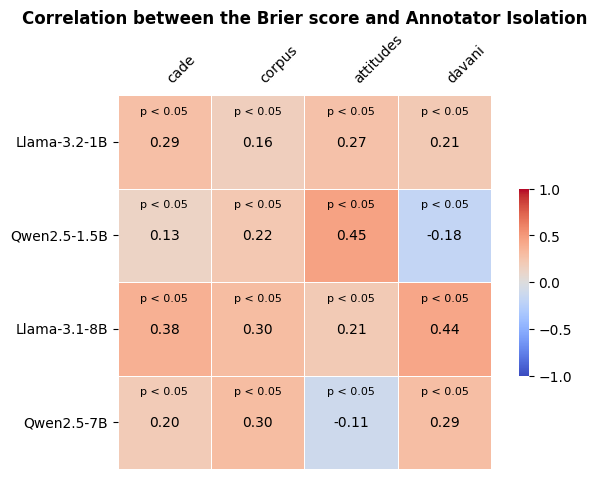

In [73]:
#Create color map between these two color
top_color = "#bf3133"  # Rosso
bottom_color = "#2596be"  # Blu

colors_ = [top_color, bottom_color]
#cmap betwen these two colors:
from matplotlib.colors import LinearSegmentedColormap
cmap = LinearSegmentedColormap.from_list('custom_cmap', colors_, N=1000)




def calcola_correlazione(file_csv):
    # Leggi il file CSV
    df = pd.read_csv(file_csv)

    # Calcola la percentuale di predizioni "mai selezionate" rispetto al totale delle predizioni per ogni modello e dataset
    model_name, dataset_name = file_csv.split('_')[3].split('Instruct')[0][0:-1], file_csv.split('_')[-1].split(".")[0]
    df['fraction_agreement']=1-df['fraction_agreement']
    corr, p_value = pearsonr(df['brier_score'], df['fraction_agreement'])
    return model_name, dataset_name, corr, p_value

# Lista dei file CSV nella cartella di output
file_csvs = [f for f in os.listdir(cartella_output) if f.startswith('step_1_') and f.endswith('.csv')]

# Definizione delle variabili e delle correlazioni di Pearson
pearsonr_values = {}
p_values = {}

# Calcola la percentuale per ogni file CSV
for file_csv in file_csvs:
    model_name, dataset_name, correlazione, p_value = calcola_correlazione(os.path.join(cartella_output, file_csv))

    pearsonr_values[(model_name, dataset_name)] = correlazione
    p_values[(model_name, dataset_name)] = p_value

# Lista ordinata delle variabili
models = []
for key in p_values.keys():
    if key[0] not in models:
        models.append(key[0])

datasets = []
for key in p_values.keys():
    if key[1] not in datasets:
        datasets.append(key[1])


models = ['Llama-3.2-1B', 'Qwen2.5-1.5B', 'Llama-3.1-8B','Qwen2.5-7B']  # Inserisci l'ordine che desideri

# Creazione della matrice vuota per tau e p-value
matrix = pd.DataFrame(np.zeros((len(models), len(datasets))), index=models, columns=datasets)
p_matrix = pd.DataFrame(np.ones((len(models), len(datasets))), index=models, columns=datasets)

# Popolamento della matrice con i valori di tau e p-value
for (var1, var2), tau in pearsonr_values.items():
    matrix.loc[var1, var2] = tau

for (var1, var2), p_val in p_values.items():
    p_matrix.loc[var1, var2] = p_val

# Creazione della heatmap
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5, square=True,
            cbar_kws={"shrink": 0.5}, xticklabels=True, yticklabels=True, annot_kws={"color": "black"}, ax=ax)

# Spostare le etichette della x in alto
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')
plt.xticks(rotation=45, ha='left')

# Aggiungere le etichette delle righe correttamente
ax.set_yticks(np.arange(len(models)) + 0.5)
ax.set_yticklabels(models, rotation=0)

# Rimozione delle tacche dell'asse Y
ax.tick_params(axis='y', bottom=False, top=False)
ax.tick_params(axis='x', bottom=False, top=False)

# Aggiungere i p-value sopra i quadrati della heatmap
for i in range(len(models)):
    for j in range(len(datasets)):
        #if i < j:  # Solo triangolo superiore
        p_val = p_matrix.iloc[i, j]
        if p_val < 0.05:  # Mostra solo p-value significativi
            text_color = "black"
            ax.text(j + 0.5, i + 0.17, f"p < 0.05", ha='center', va='center', fontsize=8, color=text_color)
        else:
            text_color = "black"
            ax.text(j + 0.5, i + 0.17, f"p ≥ 0.05", ha='center', va='center', fontsize=8, color=text_color)

plt.title('Correlation between the Brier score and Annotator Isolation', fontweight='bold')

print(pearsonr_values)
print(p_values)
# Spazio regolato
plt.subplots_adjust(left=0.2, right=0.9, top=0.823, bottom=0.2)

#save
if not os.path.exists('figures'):
    os.makedirs('figures')  
plt.savefig('figures/correlation_brier_score_annotator_isolation.pdf', format='pdf', bbox_inches='tight')
plt.show()


## R5: Model Uncertainty

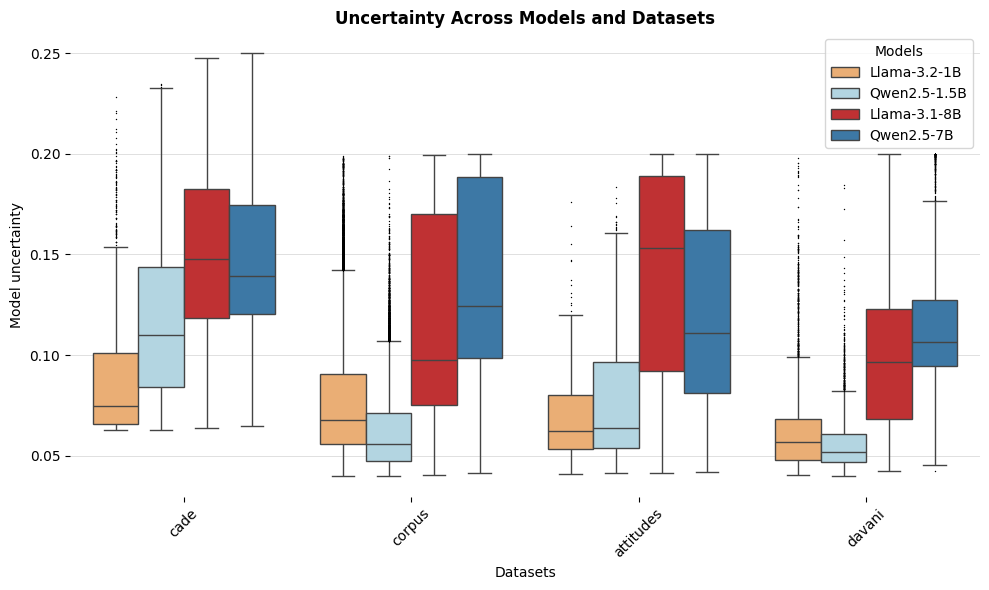

In [88]:
# Funzione per estrarre i dati necessari per il box plot
def estrai_dati_box_plot(file_csv):
    # Leggi il file CSV
    df = pd.read_csv(file_csv)

    # Raggruppa per comment_id e prendi un valore di brier_score_model unico per ogni comment_id
    df_unique = df[['comment_id', 'brier_score_model']].drop_duplicates()

    # Unisci altre informazioni come il modello e dataset per etichettare correttamente
    model_name, dataset_name = file_csv.split('_')[3].split('Instruct')[0][0:-1], file_csv.split('_')[-1].split(".")[0]

    df_unique['model_name'] = model_name
    df_unique['dataset_name'] = dataset_name

    return df_unique


# Lista dei file CSV nella cartella di output
file_csvs = [f for f in os.listdir(cartella_output) if f.startswith('step_1_') and f.endswith('.csv')]

# Crea un DataFrame vuoto per contenere i risultati
dati_box_plot = []

# Estrai i dati per ogni file CSV
for file_csv in file_csvs:
    df = estrai_dati_box_plot(os.path.join(cartella_output, file_csv))
    dati_box_plot.append(df)

# Combina tutti i risultati in un unico DataFrame
df_box_plot = pd.concat(dati_box_plot, ignore_index=True)


# Creazione del box plot
plt.figure(figsize=(10, 6))
modelli_ordinati = ['Llama-3.2-1B',  'Qwen2.5-1.5B','Llama-3.1-8B','Qwen2.5-7B']

# Impostiamo i flierprops per ridurre la dimensione delle palline (outliers)
flierprops = dict(marker='o', markerfacecolor='black', markersize=1, markeredgewidth=0)

sns.boxplot(x='dataset_name', y='brier_score_model', hue='model_name', data=df_box_plot,
            hue_order=modelli_ordinati, palette=['#fdae61','#abd9e9','#d7191c','#2c7bb6'],
            flierprops=flierprops)

# Aggiusta la formattazione
plt.title('Uncertainty Across Models and Datasets', fontweight='bold')
plt.xlabel('Datasets')
plt.ylabel('Model uncertainty')
plt.xticks(rotation=45)
plt.legend(title="Models")
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_visible(False)
plt.gca().spines['bottom'].set_visible(False)
plt.grid(axis='y', color='lightgray', linestyle='-', linewidth=0.5, zorder=0)  # Griglia orizzontale, grigia chiara

plt.tight_layout()

# Mostra il grafico

#Save in pdf
if not os.path.exists('figures'):
    os.makedirs('figures')  
plt.savefig('figures/model_uncertainty_across_models_datasets.pdf', format='pdf', bbox_inches='tight')
plt.show()



## R6: Correlation betweeen model uncertainty and hallucinations

## R7: Model performance based on Euclidean Distance and Social 